In [7]:
# IMPORTING DATA #

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [141]:
df = pd.DataFrame(pd.read_csv("exoplanet_data.csv", comment = "#"))

In [142]:
print(df.shape)
#There are 570 rows and 92 columns 

print(df.columns)

#Five strange sounding column titles:
#sy_snum
#pl_insollim
#pl_refname
#st_logg
#sy_kmag

(570, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

In [143]:
# REDUCING DATA #

In [144]:
#Planet Name
#pl_name
#Planet name most commonly used in the literature
#This is the name that most astronomers would use to refer to the planet most commonly. 

#Host Name
#hostname
#Stellar name most commonly used in the literature
#This is the name that most astronomers would most commonly use to refer to the star that the exoplanet orbits.

#Discovery Method
#discoverymethod
#Method by which the planet was first identified
#This is the analysis/method that was used by astronomers who discovered the exoplanet. 

#Spectral Type
#st_spectype
#Classification of the star based on their spectral characteristics following the Morgan-Keenan system
#This is the spectral type (OBAFGKM) of the host star of the exoplanet. O stars are the hottest and bluest, M stars are the coolest and reddest. 

#Equilibrium Temperature [K]
#pl_eqt
#The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body
#I think this means that the data is stating the planet's likely temperature, by assuming it is a blackbody, and basing predictions either on the host star's heat, or the lumonisty of the planet. 

#Planet Mass or Mass*sin(i) [Jupiter Mass]
#pl_bmassj
#Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), depending on availability, and measured in Jupiter masses
#The best estimate for a planet's mass based on the best available data, measured in Jupiter Masses. 

In [145]:
#4
df1 = df.filter(items=["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"])

In [146]:
#5
df2= df1.dropna()

In [147]:
#6
print(df2.shape)
#There are 67 rows and 6 columns in the dataset. 

print(df2.head())
print(df2.tail())

print(df1.columns)

(67, 6)
    pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
2  DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3  DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4  DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
5  DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
6  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
549   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
554   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
557   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
562       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
568  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')


In [148]:
# ANALYZE DATA #

In [149]:
#1
df2["discoverymethod"].value_counts()
#Transit, Radial Velocity, Imaging are the three methods. 
#52 were discovered by Transit, 13 by Radial Velocity, and 2 by Imaging. Transit has the most, Imaging has the least. 
#Transit: When a planet passes in front of its star, the observed brightness of the star dips; we can detect an exoplanet and its radius with this. 
#Radial Velocity: A star with a planet will also have a small orbit of its own due to the planet's gravity, causing variations in the star's radial velocity with respect to Earth. This allows astronomers to detect exoplanets and their mass.
#Imaging: Directly imaging the exoplanet by trying to block out the overhwelming light of the star using instruments. Used for larger planets.

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

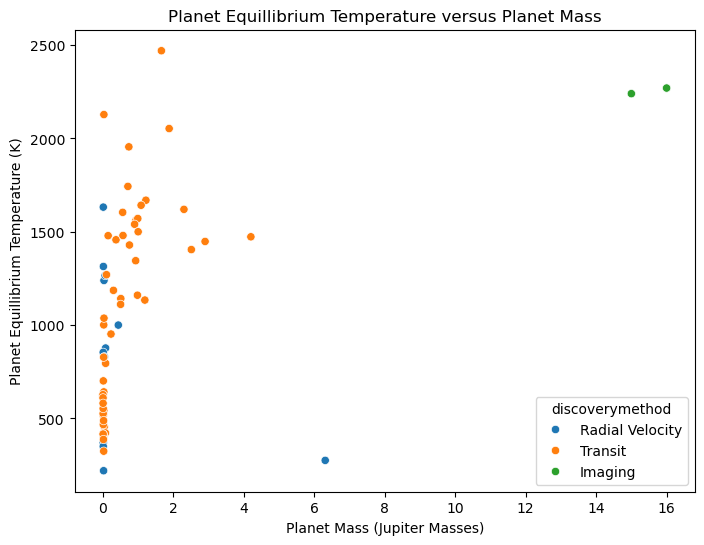

In [150]:
#2
import seaborn as sns
plt.figure(figsize=(8,6))

sns.scatterplot(x=df2["pl_bmassj"], y=df2["pl_eqt"], hue= df2["discoverymethod"])
plt.title("Planet Equillibrium Temperature versus Planet Mass")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Planet Equillibrium Temperature (K)")
plt.show()

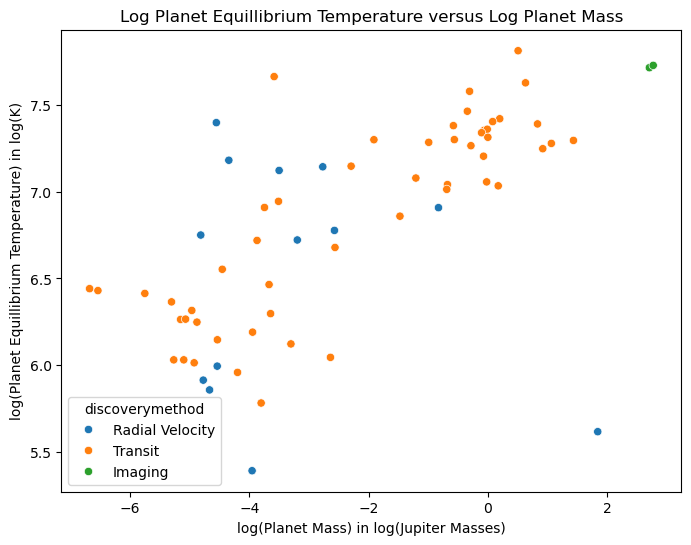

In [151]:
#3
plt.figure(figsize=(8,6))

sns.scatterplot(x=np.log(df2["pl_bmassj"]), y=np.log(df2["pl_eqt"]), hue= df2["discoverymethod"])
plt.title("Log Planet Equillibrium Temperature versus Log Planet Mass")
plt.xlabel("log(Planet Mass) in log(Jupiter Masses)")
plt.ylabel("log(Planet Equillibrium Temperature) in log(K)")
plt.show()

In [152]:
#4 
#Exoplanets found by imaging are more likely to be massive, which makes sense!

In [153]:
#5
filtered_by_mass = df2.loc[df2["pl_bmassj"]>5]

filtered_for_min = filtered_by_mass.loc[filtered_by_mass["pl_eqt"].idxmin()]

print(filtered_for_min["pl_name"])
#The coldest planet with a mass larger than five Jupiter Masses is eps Ind A b

eps Ind A b


In [154]:
#6
print(filtered_for_min)
#The name is eps Ind A b
#Its index is at 568
#275.0 K
#6.31 Jupiter Masses
#It is orbiting a star of the type K5V. Since the Sun is a G2V star, this is not a sun-like star. 

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 568, dtype: object


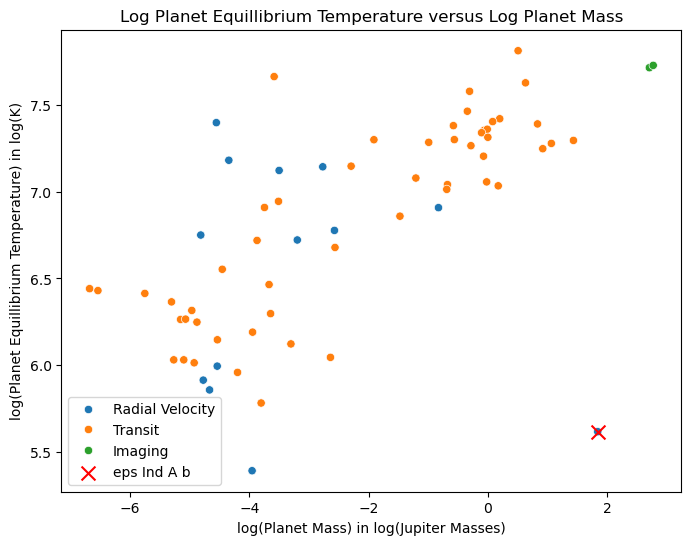

In [155]:
#7
plt.figure(figsize=(8,6))

sns.scatterplot(x=np.log(df2["pl_bmassj"]), y=np.log(df2["pl_eqt"]), hue= df2["discoverymethod"])
plt.scatter(np.log(6.31), np.log(275.0), color= "red", label = "eps Ind A b", marker ="x", s = 100)
plt.title("Log Planet Equillibrium Temperature versus Log Planet Mass")
plt.xlabel("log(Planet Mass) in log(Jupiter Masses)")
plt.ylabel("log(Planet Equillibrium Temperature) in log(K)")
plt.legend()
plt.show()

In [156]:
#CHECK YOUR ANSWER#

In [157]:
#2
#The title of this paper is "A temperate super-Jupiter imaged with JWST in the mid-infrared". 
#Previously, Radial Velocity measurements indicated that a giant planet was orbiting the star eps Ind A. The paper reveals that JWST images have found such a planet, but with different properties than expected. It is likely the only giant planet in the system and is referred to as b. 
#Yes, my answer matches the exoplanet!
#The planet is giant and extremely bright. It may be the only giant planet in its system.
#The mass and the equilibrium temperature matches what the paper reported (6.31 Jupiter Masses and 275K). 